### Questão 4

**Enunciado:** Uma empresa de SaaS (Software as a Service) quer prever se um cliente irá cancelar a assinatura (Churn = 1) ou continuar (Churn = 0) com base no número de logins mensais e no tempo de resposta do suporte técnico. Implemente o modelo de classificação que utiliza a função sigmóide para prever a probabilidade de cancelamento. Apresente a curva logística resultante e interprete o que o valor de saída representa para o setor de retenção da empresa.

**Problema:** Prever a probabilidade de um cliente cancelar a assinatura (Churn = 1) ou continuar (Churn = 0) com base no número de logins e no tempo de resposta do suporte.

**Algoritmo Apropriado:** ``Regressão Logística``.

**Justificativa:** Trata-se de um problema clássico de classificação binária, onde o resultado só pode ser duas opções (1 ou 0). A Regressão Logística é o modelo apropriado, pois utiliza a Função Sigmóide para "espremer" a saída linear em um intervalo estrito entre 0 e 1, retornando a probabilidade de o evento (Churn) ocorrer.

#### **Importando as bibliotecas**

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#### **Carregamento do Dataset**

In [14]:
try:
    # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows=1
    dados = np.loadtxt('datasets/dataset_q4.csv', delimiter=',', skiprows=1, usecols=(1, 2, 3))

    # X_features: Colunas -> [Logins Mensais, Resposta Suporte (horas)]
    X_features = dados[:, :2]

    # y: Target -> Churn (1 = Cancelou, 0 = Continuou)
    y = dados[:, 2].reshape(-1, 1)

    # Visualiza os dados
    print("X:", X_features)
    print("y:", y)

    print("\n Número de amostras:", X_features.shape[0])

except FileNotFoundError:
    print("Erro: Arquivo do dataset não encontrado.")
    exit()

X: [[20.  2.]
 [ 5. 24.]
 [18.  3.]
 [ 8. 18.]
 [25.  1.]
 [ 3. 48.]
 [15.  5.]
 [10. 12.]
 [22.  2.]
 [ 6. 36.]
 [19.  4.]
 [ 4. 20.]
 [21.  1.]
 [ 7. 15.]
 [17.  6.]]
y: [[0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]]

 Número de amostras: 15


#### **Funções Matemáticas do Modelo**

In [ ]:
def sigmoid(z):
    """Função que espreme os valores entre 0 e 1."""
    return 1 / (1 + np.exp(-z))

def normalize(X):
    """Normalização para otimizar o Gradiente Descendente."""
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / (std + 1e-8)

def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

def gradient_descent(X, y, beta, lr, epochs):
    """Algoritmo de otimização para encontrar os melhores pesos."""
    m = len(y)
    for i in range(epochs):
        h = sigmoid(X @ beta)
        gradient = (1/m) * (X.T @ (h - y))
        beta = beta - lr * gradient
    return beta

#### **Treinamento do Modelo**

In [ ]:
X_norm = normalize(X_features)
X_ready = add_bias(X_norm)

beta_inicial = np.zeros((X_ready.shape[1], 1))
taxa_aprendizado = 0.1
epocas = 500

beta_otimizado = gradient_descent(X_ready, y, beta_inicial, lr=taxa_aprendizado, epochs=epocas)

print("Pesos (Betas) otimizados encontrados:")
print(beta_otimizado)

# 4. Extração de Probabilidades
z = X_ready @ beta_otimizado
probabilidades = sigmoid(z)

Pesos (Betas) otimizados encontrados:
[[ 0.06181819]
 [-3.08520045]
 [ 2.09802356]]


#### **Plotando a Curva Logística (Sigmóide)**

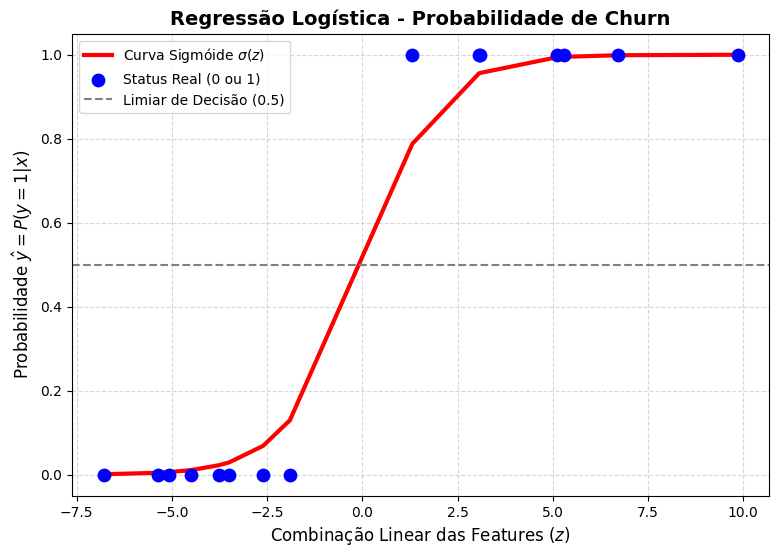

In [ ]:
# Ordenar Z para traçar a curva suavemente
z_sorted = np.sort(z, axis=0)
probs_sorted = sigmoid(z_sorted)

plt.figure(figsize=(9, 6))
plt.plot(z_sorted, probs_sorted, color='red', linewidth=3, label='Curva Sigmóide $\\sigma(z)$')
plt.scatter(z, y, color='blue', s=80, label='Status Real (0 ou 1)', zorder=5)

# Limiar de decisão
plt.axhline(0.5, color='gray', linestyle='--', label='Limiar de Decisão (0.5)')

plt.title('Regressão Logística - Probabilidade de Churn', fontsize=14, fontweight='bold')
plt.xlabel('Combinação Linear das Features ($z$)', fontsize=12)
plt.ylabel('Probabilidade $\\hat{y} = P(y=1|x)$', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### **Interpretação dos Resultados para o Negócio**

A curva sigmóide gerada converte a relação matemática entre as *features* em um valor de probabilidade entre $0$ e $1$. O eixo Y representa a probabilidade exata do cliente cancelar o serviço ($P(y=1|x)$). 

Para a equipe de retenção, se o modelo retornar $\hat{y} \ge 0.5$, prevê-se que o cliente entrará em *Churn* (Classe 1). Quanto mais próximo de 1 for o resultado gerado, maior é a chance do cliente cancelar. Dessa forma, a empresa não recebe apenas uma classificação fria, mas uma **medida de risco** (probabilidade), permitindo priorizar ações proativas naqueles clientes cujas probabilidades estejam na parte superior direita da curva logística.